In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr 
import glob

In [2]:
bed_base = "/home/eriks/primatediversity/data/gVCFs_recalling_10_12_2024/"


def read_beds(long_form):
    bed_path_x = bed_base+"{}/filteredVCF/all_samples/pos_bed_cov_based/{}_batch*_fploidy2_mploidy1.bed".format(long_form, long_form)
    bed_path_all = bed_base+"{}/filteredVCF/all_samples/pos_bed_cov_based/{}_batch*_fploidy2_mploidy2.bed".format(long_form, long_form)
    bed_l = []
    for b in glob.glob(bed_path_all):
        bed_file = pd.read_csv(b, sep="\t", names=["chrom", "start", "end"])
        bed_l.append(bed_file)
    bed_files = pd.concat(bed_l)
    bed_l = []
    for b in glob.glob(bed_path_x):
        #print(b)
        bed_file = pd.read_csv(b, sep="\t", names=["chrom", "start", "end"])
        bed_l.append(bed_file)
    if len(bed_l) > 0:
        bed_x = pd.concat(bed_l)
        bed_files = bed_files.loc[~(bed_files.chrom.isin(bed_x.chrom.unique()))]
        bed_files = pd.concat([bed_files, bed_x]).sort_values(by=["chrom", "start", "end"])
    return bed_files

def read_beds_human(zarr_path, chrX):
    bed_path_x = zarr_path+"_X.bed"
    bed_path_all = zarr_path+".bed"
    bed_file_x = pd.read_csv(bed_path_x, sep="\t", names=["chrom", "start", "end"])
    bed_file_x = bed_file_x.loc[bed_file_x.chrom == chrX]
    bed_file_aut = pd.read_csv(bed_path_all, sep="\t", names=["chrom", "start", "end"])
    bed_file_aut = bed_file_aut.loc[bed_file_aut.chrom != chrX]
    bed_files = pd.concat([bed_file_aut, bed_file_x])
    return bed_files

In [3]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [4]:
zarr_path_list = glob.glob("../human_ref_zarr_20x_inds/*/zarr*X.bed")
len(zarr_path_list)

214

In [5]:
zarr_path_list

['../human_ref_zarr_20x_inds/Pygathrix_nigripes_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Cercopithecus_pogonias_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Microcebus_griseorufus_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Nasalis_larvatus_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Hylobates_abbotti_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Trachypithecus_francoisi_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Trachypithecus_auratus_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Pithecia_hirsuta_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Microcebus_murinus_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Plecturocebus_caligatus_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Hylobates_agilis_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Macaca_cyclopis_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Saguinus_oedipus_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Nycticebus_coucang_ssp/zarr_X.bed',
 '../human_ref_zarr_20x_inds/Trachypithecus_ebenus_ssp/zarr_X.bed',
 '../human_

In [8]:
# Generating bed stats for all species which have a lifted X, in their original ref
zarr_path_list = glob.glob("../human_ref_zarr_20x_inds/*/zarr*X.bed")

ref_l = []

for zarr_path in zarr_path_list[:]:
    long_form = zarr_path.split("/")[-2]
    short_form = zarr_path.split("/")[-2].split("_")[0]
    print(long_form)
    bed_files_ref = read_beds(long_form)
    metadata_df = pd.read_csv(metadata_path+"{}_individuals.txt".format(short_form), sep="\t")
    regions_df = pd.read_csv(metadata_path+"{}_regions_and_batches.txt".format(short_form), sep="\t")
    regions_df["chr_type"] = ["chrX" if x == 2 and y == 1 else "aut" for x, y in zip(regions_df.FEMALE_PLOIDY, regions_df.MALE_PLOIDY)]
    large_contigs = regions_df.loc[(regions_df.END >= 1000000) & (regions_df.FEMALE_PLOIDY == 2)].CONTIG_ID.unique()
    bed_files_ref = bed_files_ref.loc[bed_files_ref.chrom.isin(large_contigs)]
    bed_files_ref["length"] = bed_files_ref.end-bed_files_ref.start
    bed_files_ref_mean = bed_files_ref.groupby(["chrom"])[["length"]].sum().reset_index()
    bed_files_ref_mean["end_pos"] = bed_files_ref.groupby(["chrom"])[["end"]].max().reset_index().end
    bed_files_ref_mean["chr_type"] = bed_files_ref_mean["chrom"].map(dict(zip(regions_df.CONTIG_ID, regions_df.chr_type)))
    bed_files_ref_mean["species"] = long_form
    bed_files_ref_mean["reference"] = regions_df.REFERENCE_FOLDER.iloc[0]
    ref_l.append(bed_files_ref_mean)
bed_stats_ref = pd.concat(ref_l)

bed_stats_ref.to_csv("../data/bed_stats_ref.txt", index=False, sep="\t")

Pygathrix_nigripes_ssp
Cercopithecus_pogonias_ssp
Microcebus_griseorufus_ssp
Nasalis_larvatus_ssp
Hylobates_abbotti_ssp
Trachypithecus_francoisi_ssp
Trachypithecus_auratus_ssp
Pithecia_hirsuta_ssp
Microcebus_murinus_ssp
Plecturocebus_caligatus_ssp
Hylobates_agilis_ssp
Macaca_cyclopis_ssp
Saguinus_oedipus_ssp
Nycticebus_coucang_ssp
Trachypithecus_ebenus_ssp
Cercopithecus_wolfi_ssp
Pongo_pygmaeus_ssp
Saguinus_inustus_ssp
Erythrocebus_patas_ssp
Trachypithecus_geei_ssp
Papio_ursinus_ssp
Microcebus_jonahi_ssp
Macaca_thibetana_ssp
Saguinus_mystax_ssp
Cebus_imitator_ssp
Pygathrix_nemaeus_ssp
Microcebus_tavaratra_ssp
Callithrix_geoffroyi_ssp
Eulemur_rufus_ssp
Leontopithecus_chrysomelas_ssp
Mandrillus_sphinx_ssp
Nomascus_concolor_ssp
Cheracebus_lugens_ssp
Allochrocebus_lhoesti_ssp
Piliocolobus_tephrosceles_ssp
Rhinopithecus_bieti_ssp
Leontocebus_nigricollis_ssp
Cheirogaleus_major_ssp
Saguinus_bicolor_ssp
Trachypithecus_phayrei_ssp
Pithecia_pithecia_ssp
Macaca_assamensis_ssp
Cercocebus_atys_ssp


In [9]:
bed_stats_ref

,chrom,length,end_pos,chr_type,species,reference
0,NC_044549.1,185331442,206549526,aut,Pygathrix_nigripes_ssp,Rhinopithecus_roxellana_ssp
1,NC_044550.1,169439190,195393606,aut,Pygathrix_nigripes_ssp,Rhinopithecus_roxellana_ssp
2,NC_044551.1,161867271,185514143,aut,Pygathrix_nigripes_ssp,Rhinopithecus_roxellana_ssp
3,NC_044552.1,153855296,178832108,aut,Pygathrix_nigripes_ssp,Rhinopithecus_roxellana_ssp
4,NC_044553.1,151346452,177538706,aut,Pygathrix_nigripes_ssp,Rhinopithecus_roxellana_ssp
...,...,...,...,...,...,...
194,NW_022437135.1,987508,1113306,aut,Sapajus_apella_ssp,Sapajus_apella_ssp
195,NW_022437136.1,1037132,1065087,aut,Sapajus_apella_ssp,Sapajus_apella_ssp
196,NW_022437137.1,1007441,1027765,aut,Sapajus_apella_ssp,Sapajus_apella_ssp
197,NW_022437138.1,949827,1005035,aut,Sapajus_apella_ssp,Sapajus_apella_ssp


In [10]:
len(bed_stats_ref.species.unique())

214

In [13]:
# Reading the human beds takes a long time, as they are quite fragmented and therefore large.
zarr_path_list = glob.glob("../human_ref_zarr_20x_inds/*/zarr*X.bed")

human_l = []

for zarr_path in zarr_path_list[:]:
    long_form = zarr_path.split("/")[-2]
    short_form = zarr_path.split("/")[-2].split("_")[0]
    print(zarr_path)
    bed_files_human = read_beds_human(zarr_path[:-6], 'NC_060947.1')
    bed_files_human["length"] = bed_files_human.end-bed_files_human.start
    bed_files_human_mean = bed_files_human.groupby(["chrom"])[["length"]].sum().reset_index()
    bed_files_human_mean["end_pos"] = bed_files_human.groupby(["chrom"])[["end"]].max().reset_index().end
    bed_files_human_mean["chr_type"] = ["chrX" if x == 'NC_060947.1' else "aut" for x in bed_files_human_mean["chrom"]]
    bed_files_human_mean["species"] = long_form
    bed_files_human_mean["reference"] = "Homo_sapiens_ssp"
    human_l.append(bed_files_human_mean)

bed_stats_human = pd.concat(human_l)
bed_stats_human.to_csv("../data/bed_stats_human.txt", index=False, sep="\t")

../human_ref_zarr_20x_inds/Pygathrix_nigripes_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Cercopithecus_pogonias_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Microcebus_griseorufus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Nasalis_larvatus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Hylobates_abbotti_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Trachypithecus_francoisi_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Trachypithecus_auratus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Pithecia_hirsuta_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Microcebus_murinus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Plecturocebus_caligatus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Hylobates_agilis_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Macaca_cyclopis_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Saguinus_oedipus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Nycticebus_coucang_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Trachypithecus_ebenus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Cercopithecus_wolfi_ssp/zarr_X.bed
../human_

../human_ref_zarr_20x_inds/Cheracebus_lucifer_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Cheracebus_regulus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Aotus_azarai_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Piliocolobus_gordonorum_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Cercopithecus_ascanius_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Lophocebus_aterrimus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Propithecus_tattersalli_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Cheirogaleus_sibreei_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Macaca_leonina_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Cercopithecus_nictitans_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Brachyteles_hypoxanthus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Ateles_belzebuth_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Macaca_hecki_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Cercocebus_chrysogaster_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Callithrix_jacchus_ssp/zarr_X.bed
../human_ref_zarr_20x_inds/Macaca_brunnescens_ssp/zarr_X.bed
../human_

In [14]:
bed_stats_human

,chrom,length,end_pos,chr_type,species,reference
0,NC_060925.1,170242379,248367473,aut,Pygathrix_nigripes_ssp,Homo_sapiens_ssp
1,NC_060926.1,184101076,242614027,aut,Pygathrix_nigripes_ssp,Homo_sapiens_ssp
2,NC_060927.1,154190501,201091448,aut,Pygathrix_nigripes_ssp,Homo_sapiens_ssp
3,NC_060928.1,143425926,193335817,aut,Pygathrix_nigripes_ssp,Homo_sapiens_ssp
4,NC_060929.1,136857530,181829271,aut,Pygathrix_nigripes_ssp,Homo_sapiens_ssp
...,...,...,...,...,...,...
19,NC_060944.1,40996684,66166050,aut,Sapajus_apella_ssp,Homo_sapiens_ssp
20,NC_060945.1,21092180,45053160,aut,Sapajus_apella_ssp,Homo_sapiens_ssp
21,NC_060946.1,17532260,51297094,aut,Sapajus_apella_ssp,Homo_sapiens_ssp
22,NC_060947.1,82052891,154158668,chrX,Sapajus_apella_ssp,Homo_sapiens_ssp


Some checks of the bed stats files.

In [4]:
bed_stats_ref = pd.read_csv("../data/bed_stats_ref.txt", sep="\t")

In [5]:
bed_stats_ref["percentage_covered"] = bed_stats_ref.length/bed_stats_ref.end_pos

<Axes: xlabel='percentage_covered', ylabel='Count'>

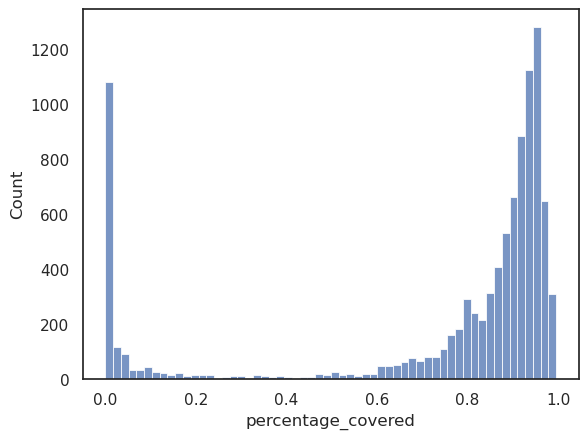

In [6]:
sns.histplot(bed_stats_ref, x="percentage_covered")

In [7]:
bed_stats_ref.loc[bed_stats_ref.percentage_covered <= 0.05]

,chrom,length,end_pos,chr_type,species,reference,percentage_covered
258,JAPYXZ010000025.1,41678,1027949,aut,Pithecia_hirsuta_ssp,Pithecia_pithecia_ssp,0.040545
394,JASSZA010000025.1,86880,3268988,aut,Saguinus_oedipus_ssp,Saguinus_oedipus_ssp,0.026577
398,JASSZA010000033.1,48928,1156641,aut,Saguinus_oedipus_ssp,Saguinus_oedipus_ssp,0.042302
400,JASSZA010000038.1,12382,1763841,aut,Saguinus_oedipus_ssp,Saguinus_oedipus_ssp,0.007020
406,JASSZA010000059.1,6722,2569430,aut,Saguinus_oedipus_ssp,Saguinus_oedipus_ssp,0.002616
...,...,...,...,...,...,...,...
8553,NW_026515581.1,12356,1256006,aut,Arctocebus_calabarensis_ssp,Nycticebus_coucang_ssp,0.009838
8554,NW_026515583.1,7280,963377,aut,Arctocebus_calabarensis_ssp,Nycticebus_coucang_ssp,0.007557
8555,NW_026515584.1,2202,820114,aut,Arctocebus_calabarensis_ssp,Nycticebus_coucang_ssp,0.002685
8556,NW_026515585.1,2333,983978,aut,Arctocebus_calabarensis_ssp,Nycticebus_coucang_ssp,0.002371


In [8]:
bed_stats_human = pd.read_csv("../data/bed_stats_human.txt", sep="\t")
bed_stats_human["percentage_covered"] = bed_stats_human.length/bed_stats_human.end_pos

<Axes: xlabel='percentage_covered', ylabel='Count'>

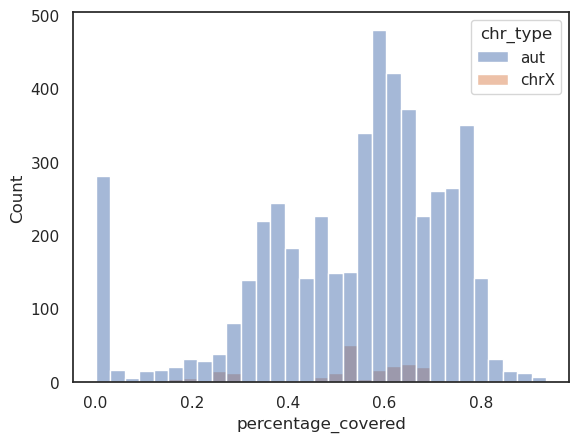

In [9]:
sns.histplot(bed_stats_human, x="percentage_covered", hue="chr_type")

In [10]:
bed_stats_human["original_reference"] = bed_stats_human.species.map(dict(zip(bed_stats_ref.species,
                                                                             bed_stats_ref.reference)))

Text(0.5, 1.0, 'Papio Cynocephalus')

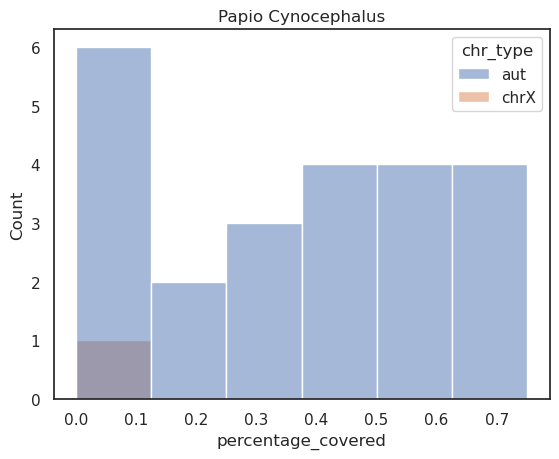

In [11]:
g = sns.histplot(bed_stats_human.loc[bed_stats_human.species == "Papio_cynocephalus_ssp"], x="percentage_covered", hue="chr_type")
g.set_title("Papio Cynocephalus")

Text(0.5, 1.0, 'Papio Cynocephalus Reference')

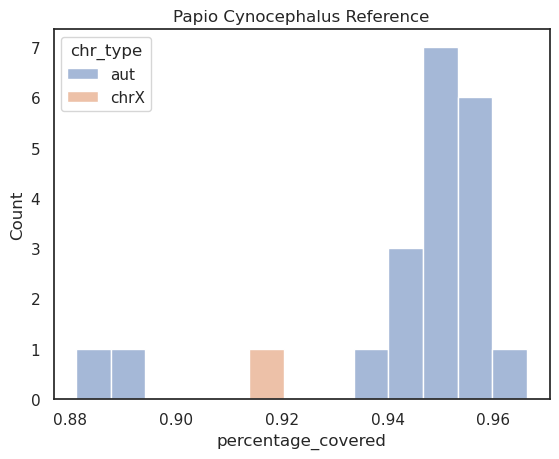

In [12]:
g = sns.histplot(bed_stats_ref.loc[bed_stats_ref.species == "Papio_cynocephalus_ssp"], x="percentage_covered", hue="chr_type")
g.set_title("Papio Cynocephalus Reference")

Text(0.5, 1.0, 'Papio Anubis Ref')

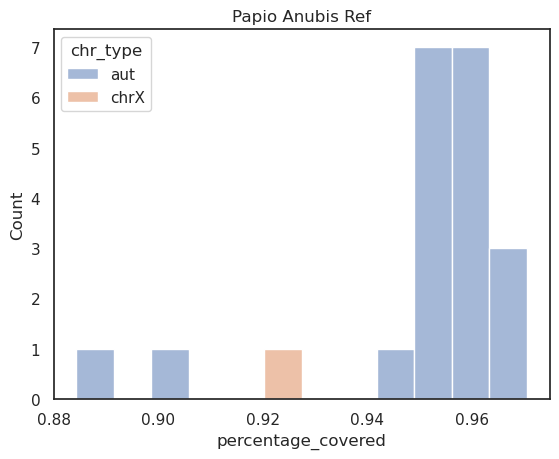

In [13]:
g = sns.histplot(bed_stats_ref.loc[bed_stats_ref.species == "Papio_anubis_ssp"], x="percentage_covered", hue="chr_type")
g.set_title("Papio Anubis Ref")

Calculating ratio of lift on chr X compared to the autosomes.

In [14]:
grouped_stats = bed_stats_human.groupby(["species", "chr_type"])[["percentage_covered"]].mean()
grouped_stats = grouped_stats.reset_index().pivot(columns="chr_type", index="species", values="percentage_covered")
grouped_stats["X cov / A cov"] = grouped_stats["chrX"]/grouped_stats["aut"]

<Axes: xlabel='X cov / A cov', ylabel='Count'>

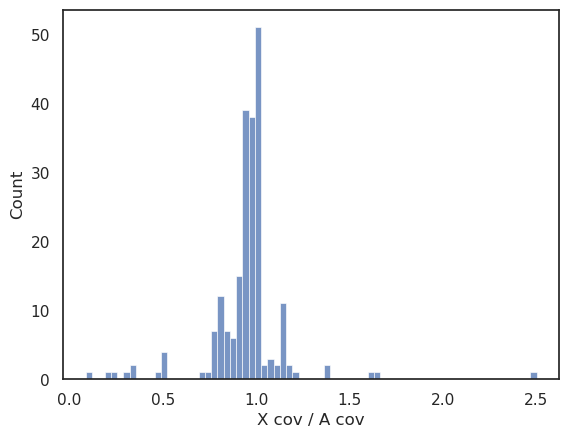

In [15]:
sns.histplot(grouped_stats, x="X cov / A cov")

In [16]:
grouped_stats.loc[grouped_stats["X cov / A cov"] <= 0.7]

chr_type,aut,chrX,X cov / A cov
species,,,
Hapalemur_griseus_ssp,0.346511,0.173912,0.501894
Hapalemur_meridionalis_ssp,0.340747,0.172607,0.506553
Lemur_catta_ssp,0.355737,0.180724,0.508029
Pan_troglodytes_ssp,0.011475,0.005408,0.471271
Papio_cynocephalus_ssp,0.362027,0.031687,0.087526
Piliocolobus_badius_ssp,0.607373,0.149034,0.245374
Piliocolobus_gordonorum_ssp,0.647787,0.218186,0.336818
Piliocolobus_kirkii_ssp,0.646012,0.190818,0.295379
Piliocolobus_tephrosceles_ssp,0.648856,0.210575,0.324532


In [31]:
grouped_stats.loc[grouped_stats.chrX < 0.3]

chr_type,aut,chrX,X cov / A cov
species,,,
Arctocebus_calabarensis_ssp,0.238005,0.189986,0.798243
Avahi_laniger_ssp,0.303040,0.264522,0.872893
Avahi_peyrierasi_ssp,0.294271,0.247005,0.839381
Cheirogaleus_major_ssp,0.342157,0.267786,0.782642
Cheirogaleus_medius_ssp,0.350827,0.273187,0.778696
Cheirogaleus_sibreei_ssp,0.326332,0.261112,0.800144
Eulemur_albifrons_ssp,0.361681,0.289450,0.800291
Eulemur_collaris_ssp,0.363202,0.294673,0.811321
Eulemur_fulvus_ssp,0.342840,0.290705,0.847931


<Axes: xlabel='aut', ylabel='chrX'>

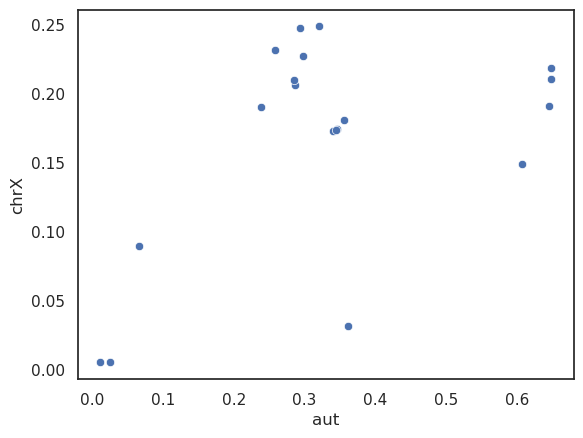

In [36]:
sns.scatterplot(grouped_stats.loc[grouped_stats.chrX <= 0.25], x="aut", y="chrX")

In [35]:
grouped_stats.loc[grouped_stats.chrX >= 0.25]

chr_type,aut,chrX,X cov / A cov
species,,,
Allenopithecus_nigroviridis_ssp,0.631109,0.645754,1.023204
Allochrocebus_lhoesti_ssp,0.657520,0.651490,0.990829
Allochrocebus_preussi_ssp,0.646400,0.644737,0.997427
Allochrocebus_solatus_ssp,0.632600,0.600472,0.949212
Alouatta_belzebul_ssp,0.486663,0.487139,1.000977
...,...,...,...
Trachypithecus_pileatus_ssp,0.632945,0.608759,0.961788
Trachypithecus_poliocephalus_ssp,0.659644,0.622133,0.943135
Trachypithecus_vetulus_ssp,0.655367,0.614241,0.937247
